In [2]:
import sys
import os
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt

# Set working directory to project root (if not already)
os.chdir('/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP')

# Add the script's directory to sys.path so we can import it
script_dir = os.path.abspath("dev/pauli_string_multiplication/direct_multiplication")
if script_dir not in sys.path:
    sys.path.insert(0, script_dir)

import llm_pauli_benchmark

In [1]:
# Define the file path
file_path = "/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/utils/prompt_irrelevant.txt"

# Read and keep only the first 200,000 lines
with open(file_path, 'r') as f:
    first_200k_lines = [next(f) for _ in range(200000)]

# Overwrite the file with the first 200,000 lines
with open(file_path, 'w') as f:
    f.writelines(first_200k_lines)

print("File truncated to first 200,000 lines.")

File truncated to first 200,000 lines.


In [3]:
file_path = "dev/pauli_string_multiplication/direct_multiplication/utils/prompt_irrelevant.txt"

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        text = f.read()
    
    print(f"Total characters: {len(text)}")
    print(f"Total words: {len(text.split())}")
    print(f"Total lines: {len(text.splitlines())}")
else:
    print("File not found")

Total characters: 103212392
Total words: 19411214
Total lines: 200000


In [ ]:
# Define parameter ranges
N_values = [20]
batch_sizes = [10]
num_iterations_list = [20]
L_irr_values = list(reversed(range(0,10*10**4,10**4)))  # Different levels of distraction
llm_pauli_benchmark.SAVE_LLM_RESPONSE = False

# Set model configuration
llm_pauli_benchmark.LLM_BACKEND = "gemini"  # or "openai" or "gemini"
llm_pauli_benchmark.MODEL_NAME = "gemini-2.5-flash"  # or any other model name

# Run all combinations
for N, batch_size, num_iterations, L_irr in product(N_values, batch_sizes, num_iterations_list, L_irr_values):
    llm_pauli_benchmark.N = N
    llm_pauli_benchmark.batch_size = batch_size
    llm_pauli_benchmark.num_iterations = num_iterations
    llm_pauli_benchmark.L_irr = L_irr  # Set the irrelevant text length
    print(f"\nRunning benchmark: N={N}, batch_size={batch_size}, iterations={num_iterations}, L_irr={L_irr}")
    llm_pauli_benchmark.main()
    print("Finished.\n")

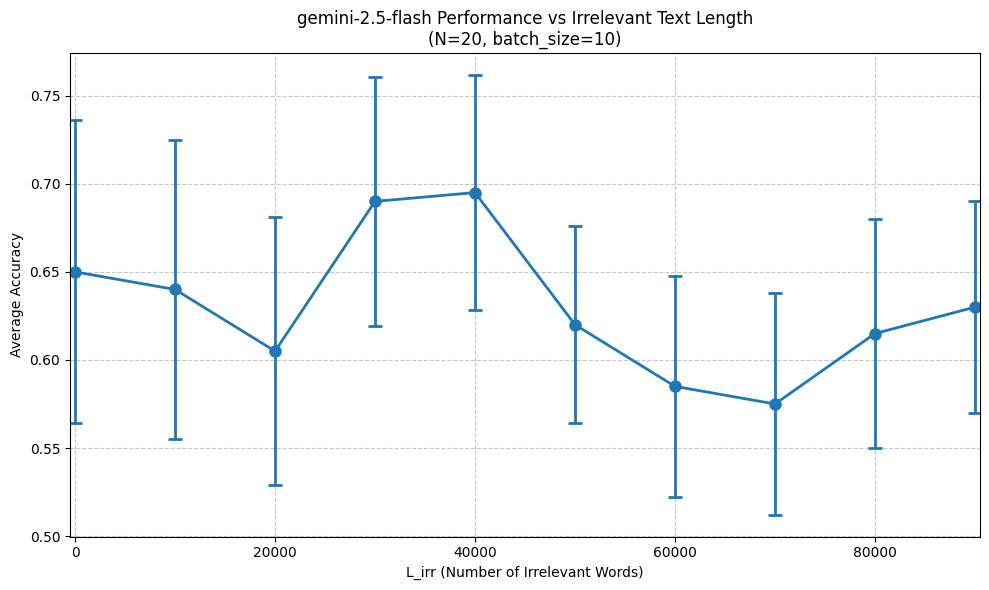


Results for gemini-2.5-flash (N=20, batch_size=10):
------------------------------------------------------------
L_irr	Mean Accuracy	Std Error	Sample Count
------------------------------------------------------------
0.0	0.6500		0.0860		20.0
10000.0	0.6400		0.0850		20.0
20000.0	0.6050		0.0763		20.0
30000.0	0.6900		0.0707		20.0
40000.0	0.6950		0.0667		20.0
50000.0	0.6200		0.0560		20.0
60000.0	0.5850		0.0625		20.0
70000.0	0.5750		0.0628		20.0
80000.0	0.6150		0.0650		20.0
90000.0	0.6300		0.0603		20.0


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Parameters
model_name = "gemini-2.5-flash"
N = 20
batch_size = 10
records_base = "dev/Pauli_string_dev/dev_test_pauli_string_multiplication/records"

# Load the data
csv_path = os.path.join(records_base, model_name, "accuracy_summary.csv")
df = pd.read_csv(csv_path)

# Filter data for specific N and batch_size
df_filtered = df[(df['N'] == N) & (df['batch_size'] == batch_size)]

# Group by L_irr and calculate mean accuracy and standard error
grouped = df_filtered.groupby('L_irr')['accuracy'].agg(['mean', 'std', 'count']).reset_index()
grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])  # Standard error of the mean

# Sort by L_irr
grouped = grouped.sort_values('L_irr')

# Create the plot
plt.figure(figsize=(10, 6))

# Plot with error bars (you can set show_error_bars = False to hide them)
show_error_bars = True  # Set to False to hide error bars

if show_error_bars:
    plt.errorbar(grouped['L_irr'], grouped['mean'], yerr=grouped['sem'], 
                marker='o', linewidth=2, markersize=8, capsize=5, capthick=2)
else:
    plt.plot(grouped['L_irr'], grouped['mean'], marker='o', linewidth=2, markersize=8)

plt.xlabel('L_irr (Number of Irrelevant Words)')
plt.ylabel('Average Accuracy')
plt.title(f'{model_name} Performance vs Irrelevant Text Length\n(N={N}, batch_size={batch_size})')
plt.grid(True, linestyle='--', alpha=0.7)

# Add some padding to x-axis
plt.xlim(-500, max(grouped['L_irr']) + 500)

plt.tight_layout()
plt.show()

# Print numerical results
print(f"\nResults for {model_name} (N={N}, batch_size={batch_size}):")
print("-" * 60)
print("L_irr\tMean Accuracy\tStd Error\tSample Count")
print("-" * 60)
for _, row in grouped.iterrows():
    print(f"{row['L_irr']}\t{row['mean']:.4f}\t\t{row['sem']:.4f}\t\t{row['count']}")

In [6]:
reversed_list = list(reversed(range(0,1000000,100000)))
print(reversed_list)

[900000, 800000, 700000, 600000, 500000, 400000, 300000, 200000, 100000, 0]


[900000, 800000, 700000, 600000, 500000, 400000, 300000, 200000, 100000, 0]